In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.shape

(768, 9)

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [10]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
df.select_dtypes(include = 'number').columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [ ]:
# graph represention of data

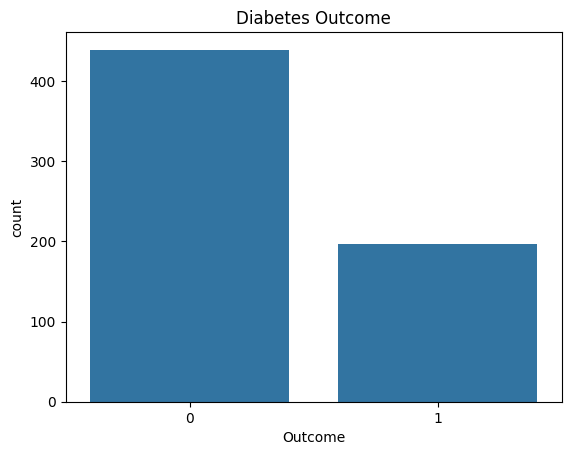

In [14]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome")
plt.show()

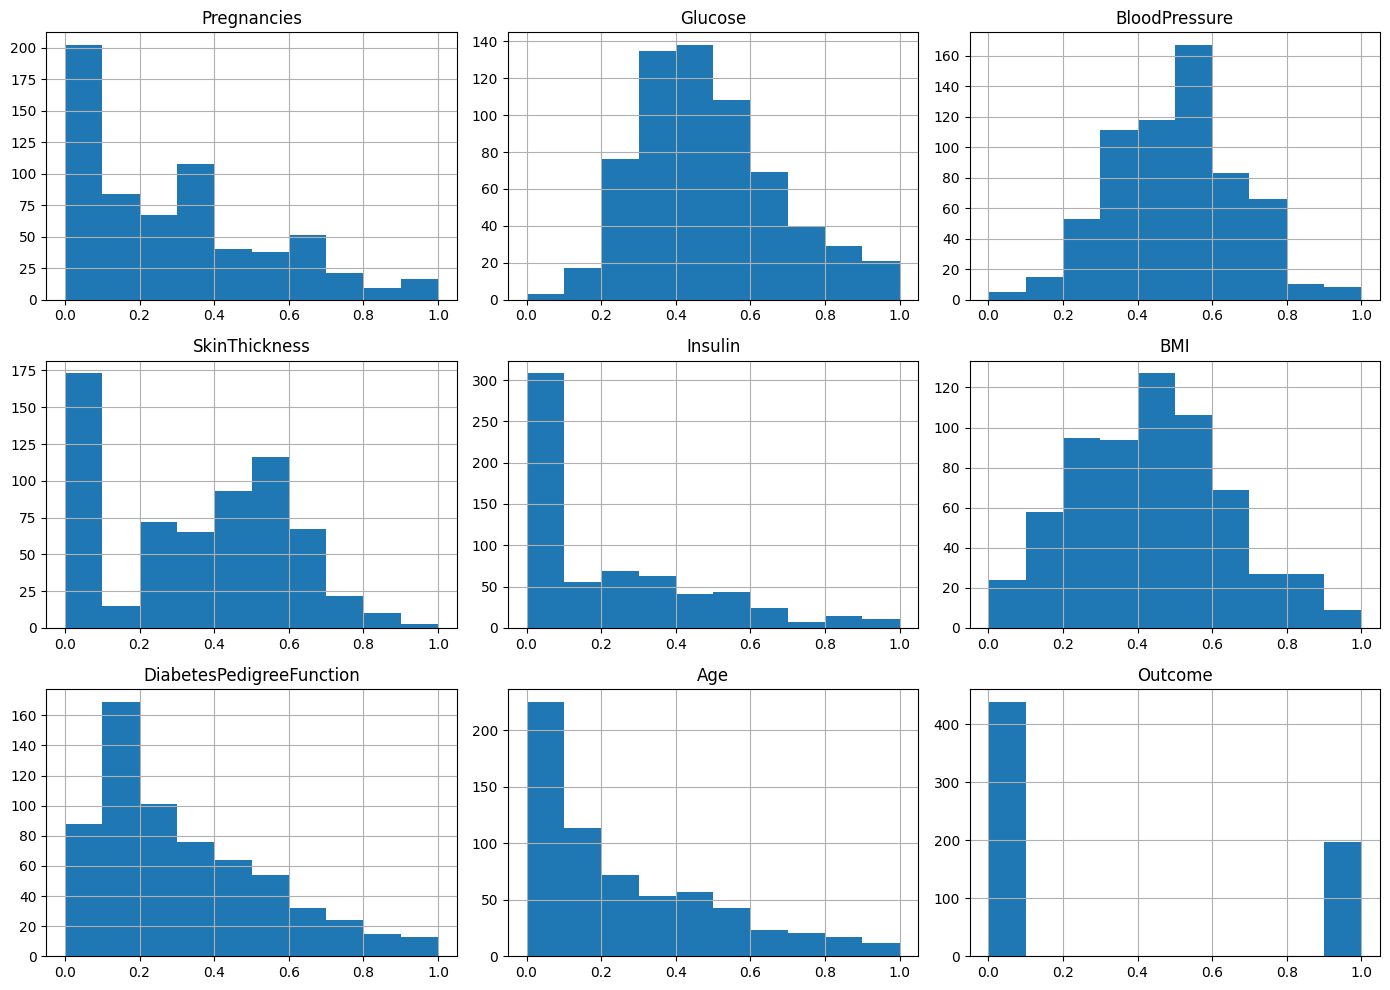

In [9]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

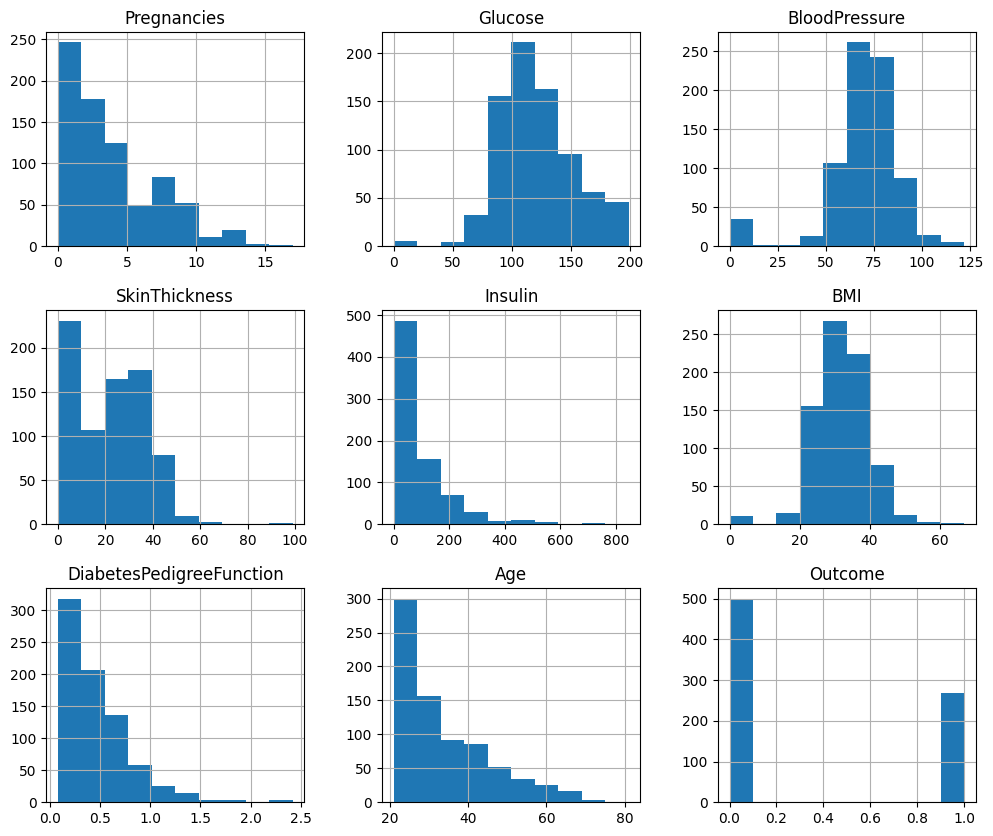

In [13]:
df.hist(figsize=(12,10))
plt.show()

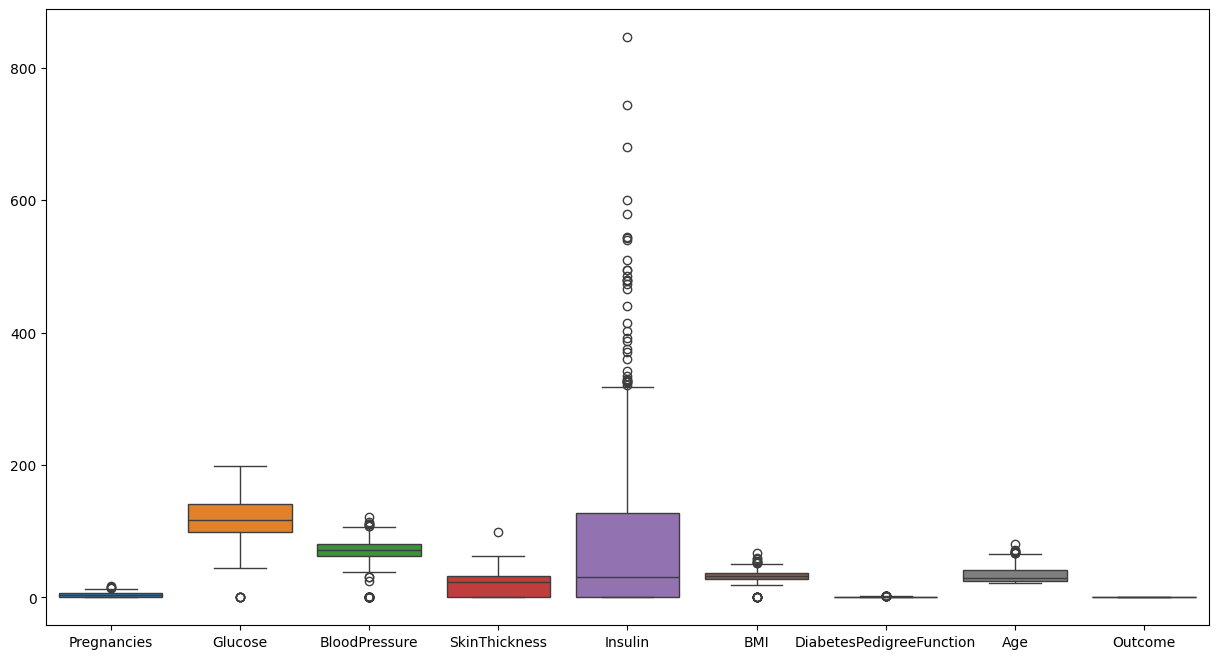

In [14]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.show()

In [4]:
columns = df.columns[:-1]
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]
print(df.shape)

(636, 9)


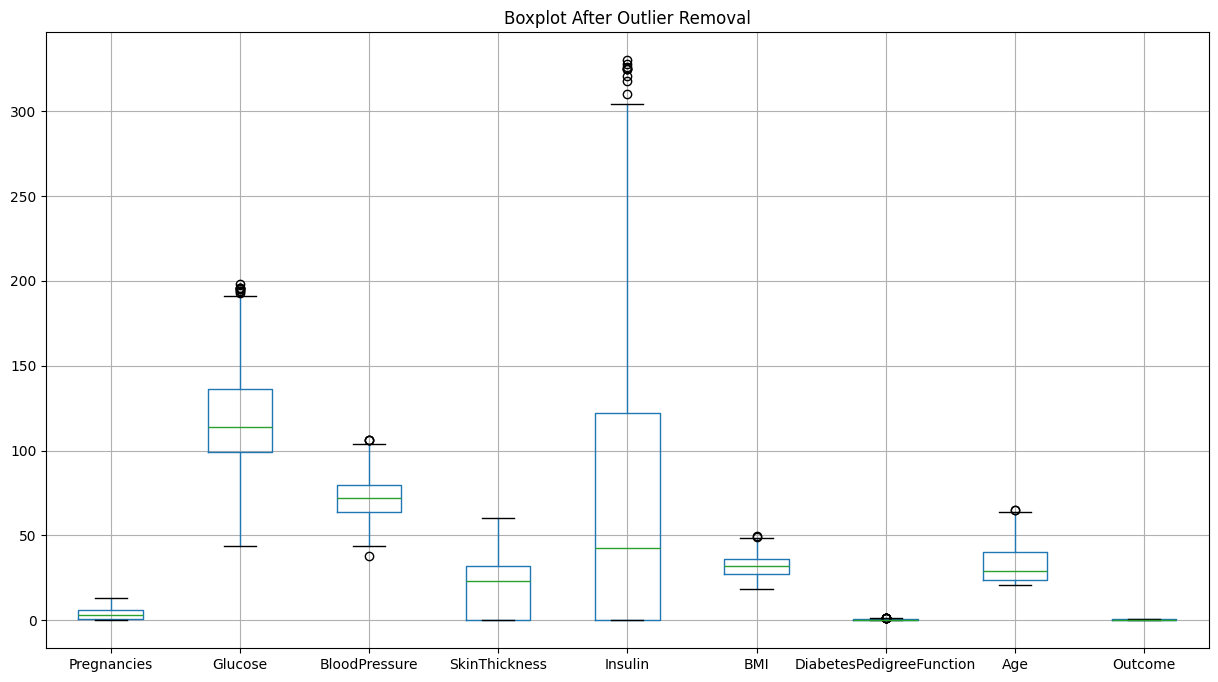

In [5]:
plt.figure(figsize=(15,8))
df.boxplot()
plt.title("Boxplot After Outlier Removal")
plt.show()

In [15]:
corr=df.corr()
print(corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

In [6]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
scaler = MinMaxScaler()
feature_columns = df.columns[:-1]
df[feature_columns] = scaler.fit_transform(df[feature_columns])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.461538,0.675325,0.500000,0.583333,0.000000,0.490446,0.506458,0.659091,1
1,0.076923,0.266234,0.411765,0.483333,0.000000,0.267516,0.251845,0.227273,0
2,0.615385,0.902597,0.382353,0.000000,0.000000,0.162420,0.547970,0.250000,1
3,0.076923,0.292208,0.411765,0.383333,0.284848,0.315287,0.082103,0.000000,0
5,0.384615,0.467532,0.529412,0.000000,0.000000,0.235669,0.113469,0.204545,0


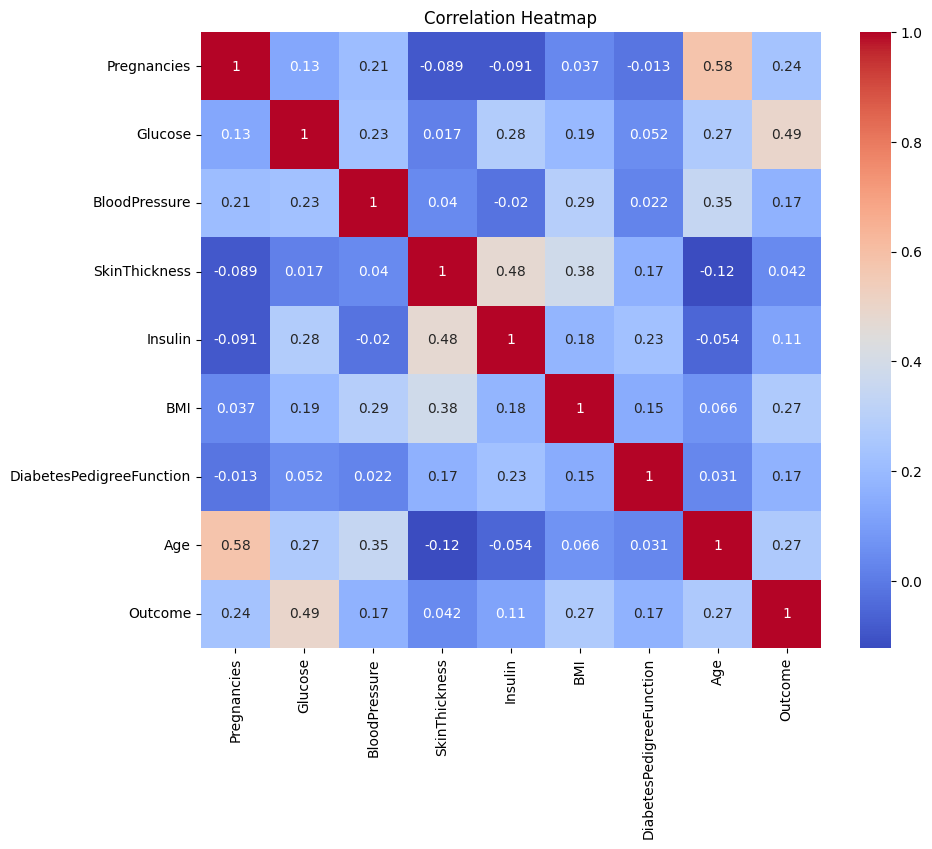

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

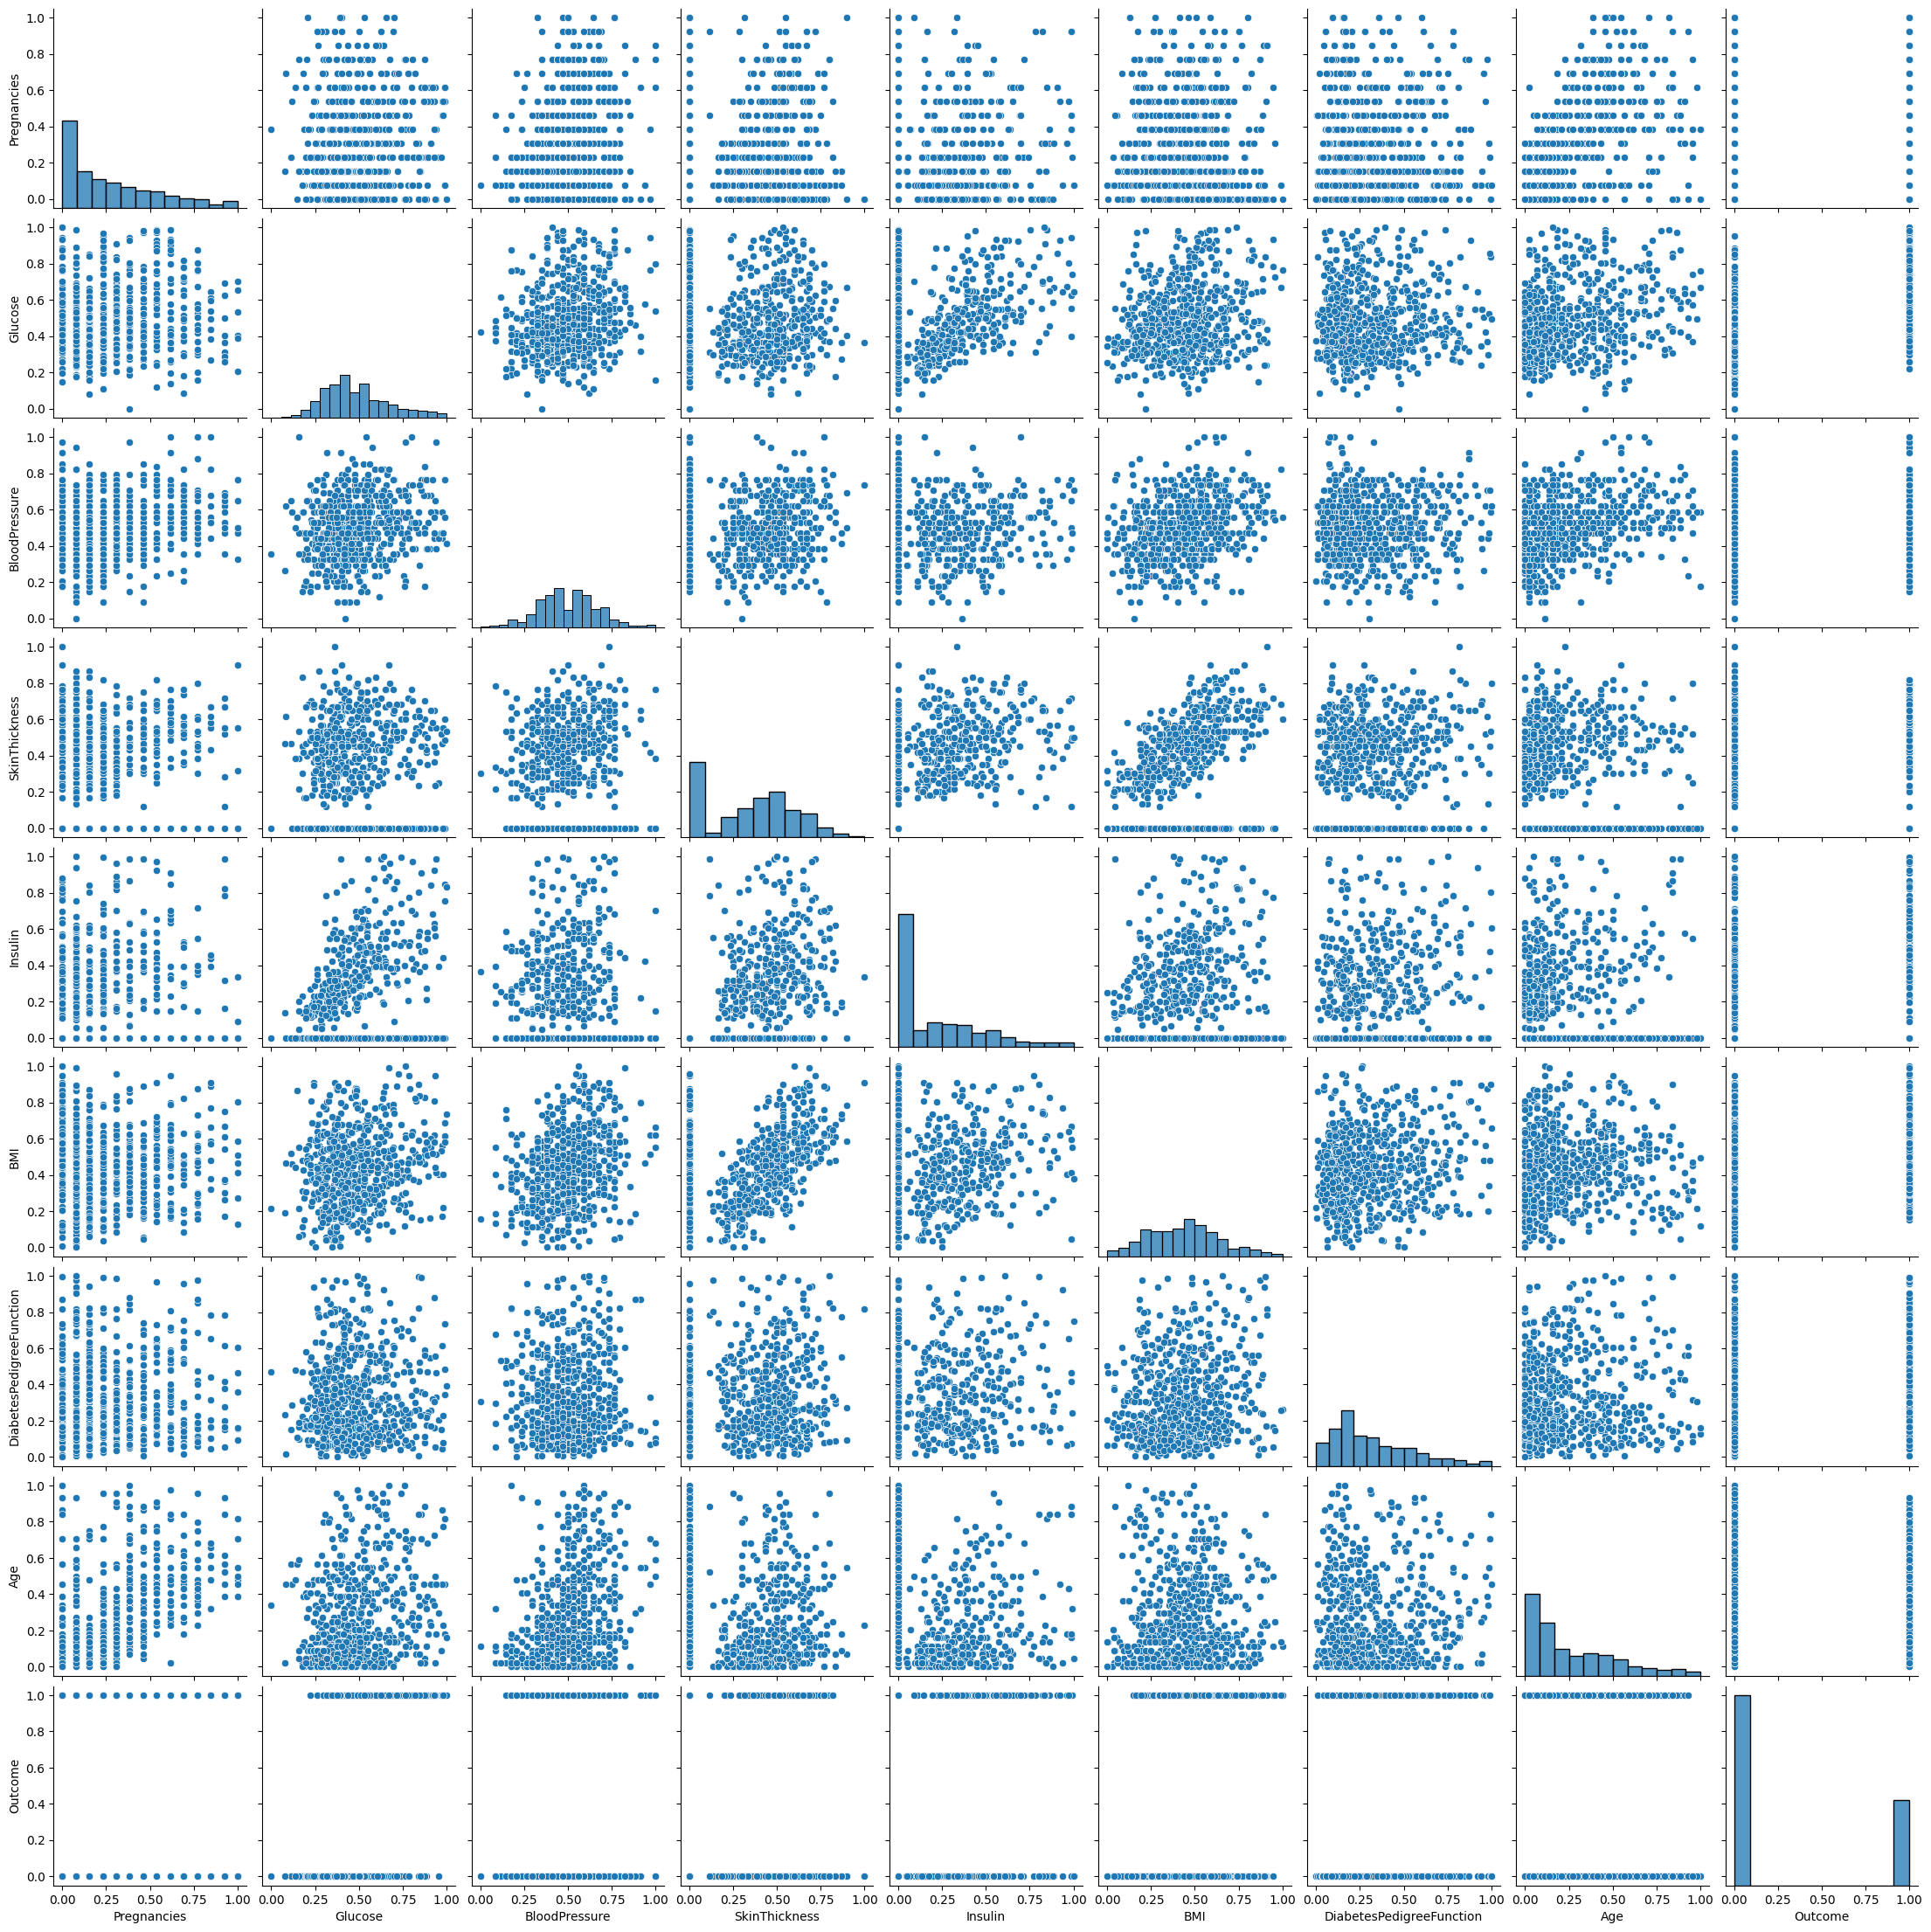

In [12]:
sns.pairplot(df)
plt.show()

In [4]:
df["Outcome"].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [5]:
zero_columns=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(zero_columns)

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
import numpy as np

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df[zero_columns]= df[zero_columns].replace(0,np.nan)

In [10]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [3]:
# just to learn linear regressoin 
# how it worked and how to use them

In [15]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
X = df.drop(columns=["BMI","Outcome"])
y = df["BMI"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
print("Intercept :")
print(model.intercept_)
print()
print("Coefficients :")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Intercept :
0.10847550474795253

Coefficients :
Pregnancies : -0.0067458770266226
Glucose : 0.21000829179369085
BloodPressure : 0.25893868070226456
SkinThickness : 0.2957600469102522
Insulin : -0.06238964125916434
DiabetesPedigreeFunction : 0.07598542815210026
Age : -0.02774594462096469


In [20]:
y_pred = model.predict(X_test)
print("First 10 Predictions")
for actual, pred in zip(y_test[:10], y_pred[:10]):
    print("Actual =", actual, " Predicted =", round(pred,2))

First 10 Predictions
Actual = 0.5095541401273885  Predicted = 0.59
Actual = 0.4681528662420381  Predicted = 0.51
Actual = 0.6815286624203821  Predicted = 0.32
Actual = 0.3726114649681528  Predicted = 0.41
Actual = 0.2993630573248408  Predicted = 0.38
Actual = 0.570063694267516  Predicted = 0.49
Actual = 0.4681528662420381  Predicted = 0.42
Actual = 0.6114649681528662  Predicted = 0.48
Actual = 0.16878980891719741  Predicted = 0.26
Actual = 0.5095541401273885  Predicted = 0.3


In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MSE : 0.022476808958692585
RMSE : 0.14992267659928096
R2 Score : 0.31068133363247474


In [23]:
# Part B : Gradient Descent

In [24]:
X = X.values
y = y.values

In [25]:
mean = X.mean(axis=0)
std = X.std(axis=0)
X = (X - mean) / std

In [26]:
X = np.c_[np.ones(len(X)), X]

In [27]:
m = len(y)
n = X.shape[1]
weights = np.zeros(n)
learning_rate = 0.01
epochs = 5000
loss_history = []

In [28]:
for epoch in range(epochs):

    predictions = X.dot(weights)
    error = predictions - y
    loss = (1/m) * np.sum(error**2)
    loss_history.append(loss)
    gradient = (2/m) * X.T.dot(error)
    weights = weights - learning_rate * gradient
    if epoch % 500 == 0:
        print("Epoch:",epoch," Loss:",loss)

Epoch: 0  Loss: 0.23342215268406158
Epoch: 500  Loss: 0.031033137898865828
Epoch: 1000  Loss: 0.03103287758083475
Epoch: 1500  Loss: 0.031032877531227257
Epoch: 2000  Loss: 0.031032877531217768
Epoch: 2500  Loss: 0.031032877531217768
Epoch: 3000  Loss: 0.031032877531217768
Epoch: 3500  Loss: 0.031032877531217768
Epoch: 4000  Loss: 0.031032877531217768
Epoch: 4500  Loss: 0.031032877531217768


In [29]:
print("Bias :")
print(weights[0])
print()
print("Weights")
for feature, w in zip(df.drop(columns=["BMI","Outcome"]).columns, weights[1:]):
    print(feature,":",w)

Bias :
0.4383487561591142

Weights
Pregnancies : 0.0022151473389534454
Glucose : 0.030457287862438946
BloodPressure : 0.04949595372005488
SkinThickness : 0.07820832308946947
Insulin : -0.012689495683110185
DiabetesPedigreeFunction : 0.01751848627535981
Age : -0.0048235687335804215


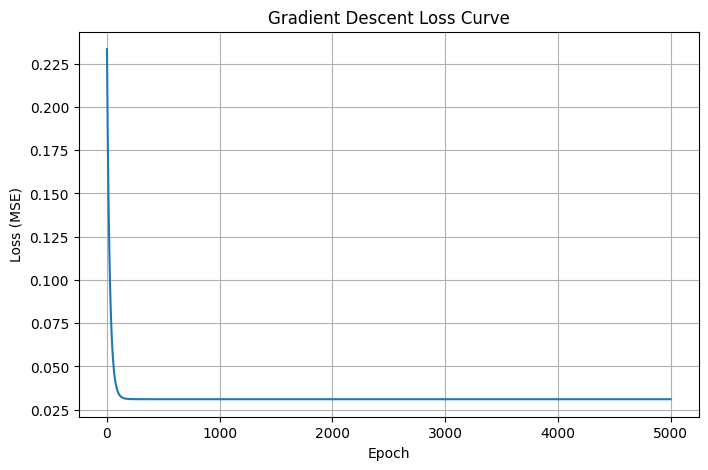

In [30]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Loss Curve")
plt.grid(True)
plt.show()

In [31]:
print("------------- SKLEARN -------------")
print("Intercept")
print(model.intercept_)

print()

for feature, coef in zip(df.drop(columns=["BMI","Outcome"]).columns,
                         model.coef_):
    print(feature,coef)

print()

print("----------- GRADIENT DESCENT -----------")
print("Bias")
print(weights[0])

print()

for feature,w in zip(df.drop(columns=["BMI","Outcome"]).columns,
                     weights[1:]):
    print(feature,w)

------------- SKLEARN -------------
Intercept
0.10847550474795253

Pregnancies -0.0067458770266226
Glucose 0.21000829179369085
BloodPressure 0.25893868070226456
SkinThickness 0.2957600469102522
Insulin -0.06238964125916434
DiabetesPedigreeFunction 0.07598542815210026
Age -0.02774594462096469

----------- GRADIENT DESCENT -----------
Bias
0.4383487561591142

Pregnancies 0.0022151473389534454
Glucose 0.030457287862438946
BloodPressure 0.04949595372005488
SkinThickness 0.07820832308946947
Insulin -0.012689495683110185
DiabetesPedigreeFunction 0.01751848627535981
Age -0.0048235687335804215


# Part 2: Classification Modeling & Frontend Integration

In this section, we train multiple machine learning classification algorithms to predict diabetes outcome (`0` = Non-Diabetic, `1` = Diabetic), compare their test accuracy, select the highest performing model, and export the winning model pipeline directly to our web application frontend.

In [51]:
# 1. Data Preprocessing & Setup for Clinical Classification
import json
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load clean clinical data
df_model = pd.read_csv('diabetes.csv')

# In clinical measurements, biological zeros in Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI are missing values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_model[zero_cols] = df_model[zero_cols].replace(0, np.nan)

feature_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
target_col = 'Outcome'

X = df_model[feature_cols]
y = df_model[target_col]

# 80/20 Stratified train-test split to preserve outcome proportion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total dataset records: {len(df_model)}')
print(f'Training set size: {len(X_train)} samples | Test set size: {len(X_test)} samples')
print(f'Missing value counts after marking biological zeros:\n{df_model[zero_cols].isnull().sum()}')


Total dataset records: 768
Training set size: 614 samples | Test set size: 154 samples
Missing value counts after marking biological zeros:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### 2. Define Candidate Classification Algorithms

We benchmark 10 classification algorithms spanning linear models, tree-based models, boosting ensembles, bagging ensembles, support vector machines, and probabilistic classifiers:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Support Vector Machine (SVC)**
4. **Decision Tree Classifier**
5. **Random Forest Classifier**
6. **AdaBoost Classifier**
7. **Gradient Boosting Classifier**
8. **XGBoost Classifier**
9. **Gaussian Naive Bayes**
10. **Extra Trees Classifier**

In [52]:
# Candidate classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=9),
    'Support Vector Machine (SVC)': SVC(probability=True, kernel='rbf', C=1.0, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=120, max_depth=8, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=60, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, n_estimators=100, max_depth=4),
    'Gaussian Naive Bayes': GaussianNB(),
    'Extra Trees': ExtraTreesClassifier(n_estimators=120, random_state=42)
}

print(f'Configured {len(candidate_models)} classification models for benchmarking.')


Configured 10 classification models for benchmarking.


### 3. Train and Evaluate Each Model using Scikit-Learn Pipeline

Each candidate model is wrapped in an end-to-end `Pipeline` containing:
- `SimpleImputer(strategy='median')`: imputes missing biological values
- `StandardScaler()`: scales features to zero mean and unit variance
- `classifier`: the ML classification algorithm

This encapsulates preprocessing and eliminates data leakage, enabling seamless deployment to the web app.

In [53]:
# Train, cross-validate, and evaluate all classification models
results = []
trained_pipelines = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=' * 85)
print(f"{'Model Name':<30} {'Accuracy':<12} {'F1-Score':<10} {'ROC-AUC':<10} {'5-Fold CV Acc':<12}")
print('=' * 85)

for name, clf in candidate_models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', clf)
    ])
    
    # 5-fold cross-validation on training data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Fit pipeline on training set
    pipeline.fit(X_train, y_train)
    
    # Predict on held-out test set
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.0
    cm = confusion_matrix(y_test, y_pred).tolist()
    
    record = {
        'name': name,
        'accuracy': round(float(acc) * 100, 2),
        'precision': round(float(prec) * 100, 2),
        'recall': round(float(rec) * 100, 2),
        'f1_score': round(float(f1), 4),
        'roc_auc': round(float(auc), 4),
        'cv_mean_accuracy': round(float(cv_scores.mean()) * 100, 2),
        'cv_std': round(float(cv_scores.std()) * 100, 2),
        'confusion_matrix': cm
    }
    results.append(record)
    trained_pipelines[name] = pipeline
    
    print(f"{name:<30} {record['accuracy']:>6.2f}%      {record['f1_score']:>8.4f}   {record['roc_auc']:>8.4f}   {record['cv_mean_accuracy']:>6.2f}% (+/- {record['cv_std']:.2f}%)")

print('=' * 85)


Model Name                     Accuracy     F1-Score   ROC-AUC    5-Fold CV Acc
Logistic Regression             70.78%        0.5455     0.8130    78.82% (+/- 1.91%)
K-Nearest Neighbors (KNN)       74.03%        0.6226     0.7951    75.57% (+/- 3.58%)
Support Vector Machine (SVC)    74.03%        0.6000     0.7964    78.01% (+/- 1.36%)
Decision Tree                   75.97%        0.6783     0.7622    72.96% (+/- 1.68%)
Random Forest                   74.03%        0.5833     0.8106    77.36% (+/- 2.05%)
AdaBoost                        75.32%        0.6200     0.8158    77.04% (+/- 0.60%)
Gradient Boosting               75.97%        0.6263     0.8306    75.41% (+/- 2.03%)
XGBoost                         77.27%        0.6602     0.8207    73.29% (+/- 2.99%)
Gaussian Naive Bayes            70.13%        0.5965     0.7646    76.23% (+/- 2.80%)
Extra Trees                     72.73%        0.5962     0.8086    75.73% (+/- 1.38%)


### 4. Benchmark Leaderboard & Accuracy Comparison Visualization

We rank all models by **Test Accuracy** (with F1-Score and ROC-AUC as tie-breakers) to identify which classification model achieves the highest accuracy.

=== MODEL BENCHMARK LEADERBOARD ===


,Model Name,Test Accuracy (%),F1-Score,ROC-AUC,CV Accuracy (%),Precision (%),Recall (%)
0,XGBoost,77.27,0.6602,0.8207,73.29,69.39,62.96
1,Decision Tree,75.97,0.6783,0.7622,72.96,63.93,72.22
2,Gradient Boosting,75.97,0.6263,0.8306,75.41,68.89,57.41
3,AdaBoost,75.32,0.6200,0.8158,77.04,67.39,57.41
4,K-Nearest Neighbors (KNN),74.03,0.6226,0.7951,75.57,63.46,61.11
5,Support Vector Machine (SVC),74.03,0.6000,0.7964,78.01,65.22,55.56
6,Random Forest,74.03,0.5833,0.8106,77.36,66.67,51.85
7,Extra Trees,72.73,0.5962,0.8086,75.73,62.00,57.41
8,Logistic Regression,70.78,0.5455,0.8130,78.82,60.00,50.00
9,Gaussian Naive Bayes,70.13,0.5965,0.7646,76.23,56.67,62.96


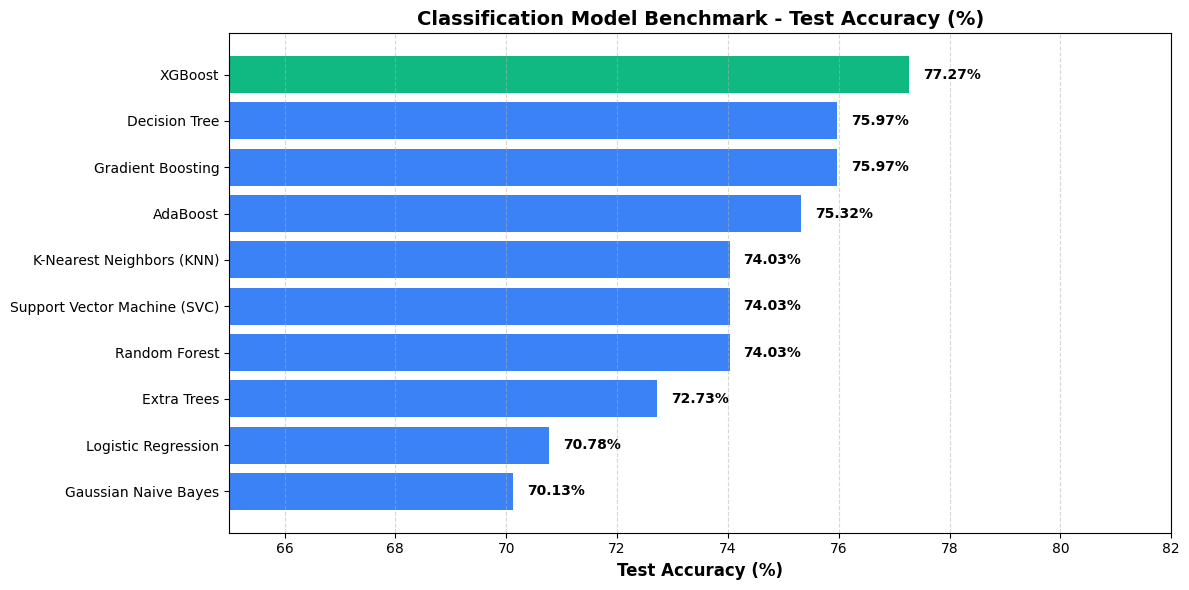

In [54]:
# Sort by test accuracy descending
results.sort(key=lambda x: (x['accuracy'], x['f1_score'], x['roc_auc']), reverse=True)

leaderboard_df = pd.DataFrame(results)[[
    'name', 'accuracy', 'f1_score', 'roc_auc', 'cv_mean_accuracy', 'precision', 'recall'
]]
leaderboard_df.columns = [
    'Model Name', 'Test Accuracy (%)', 'F1-Score', 'ROC-AUC', 'CV Accuracy (%)', 'Precision (%)', 'Recall (%)'
]

print('=== MODEL BENCHMARK LEADERBOARD ===')
display(leaderboard_df)

# Visual Comparison Plot
plt.figure(figsize=(12, 6))
colors = ['#10b981' if i == 0 else '#3b82f6' for i in range(len(leaderboard_df))]
bars = plt.barh(leaderboard_df['Model Name'][::-1], leaderboard_df['Test Accuracy (%)'][::-1], color=colors[::-1])
plt.xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Classification Model Benchmark - Test Accuracy (%)', fontsize=14, fontweight='bold')
plt.xlim(65, 82)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.25, bar.get_y() + bar.get_height() / 2, f'{w:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### 5. Detailed Diagnostics: Classification Report & Confusion Matrix for Winner

WINNING MODEL: XGBoost with 77.27% Test Accuracy!

                  precision    recall  f1-score   support

Non-Diabetic (0)       0.81      0.85      0.83       100
    Diabetic (1)       0.69      0.63      0.66        54

        accuracy                           0.77       154
       macro avg       0.75      0.74      0.74       154
    weighted avg       0.77      0.77      0.77       154



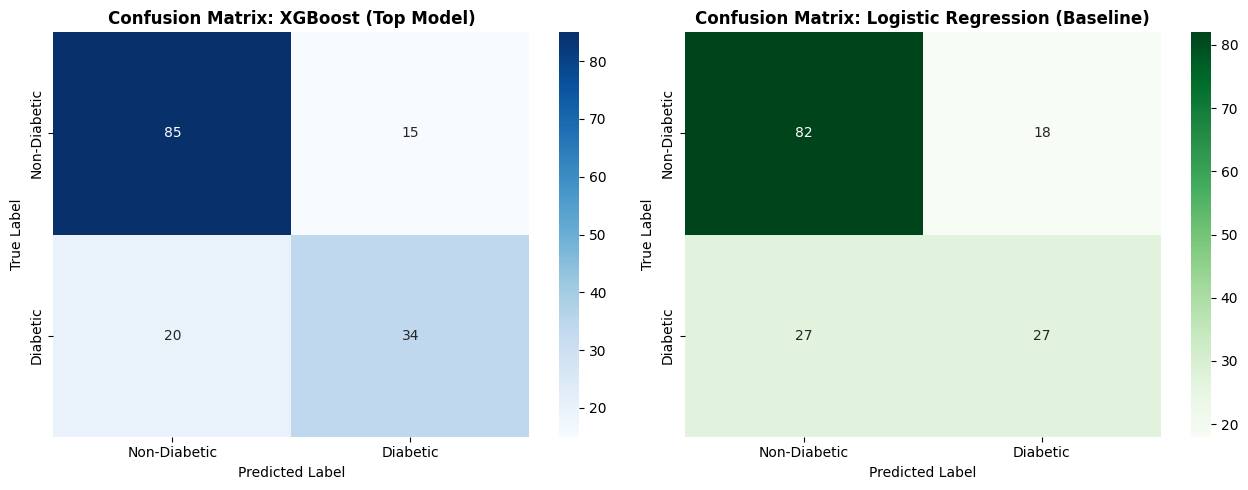

In [55]:
best_name = results[0]['name']
best_pipeline = trained_pipelines[best_name]

print(f'WINNING MODEL: {best_name} with {results[0]["accuracy"]}% Test Accuracy!\n')
y_pred_best = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix for winner
cm_best = np.array(results[0]['confusion_matrix'])
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_title(f'Confusion Matrix: {best_name} (Top Model)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion matrix for Logistic Regression baseline
lr_rec = [r for r in results if r['name'] == 'Logistic Regression'][0]
cm_lr = np.array(lr_rec['confusion_matrix'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[1].set_title('Confusion Matrix: Logistic Regression (Baseline)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


### 6. Export Winning Model Pipeline & Sync with Frontend Web App

Here we serialize the winning pipeline to `best_model.pkl` and output `models_summary.json`. This integrates directly with the Flask API and React frontend.

In [56]:
# 1. Save winning pipeline to best_model.pkl
best_result = results[0]
best_name = best_result['name']
best_pipeline = trained_pipelines[best_name]

pkl_path = 'best_model.pkl'
joblib.dump(best_pipeline, pkl_path)
print(f'[OK] Serialized winning model pipeline ({best_name}) to: {os.path.abspath(pkl_path)}')

# 2. Save benchmark metrics to models_summary.json
summary_data = {
    'generated_at': datetime.now().isoformat(),
    'dataset': {
        'total_samples': int(len(df_model)),
        'train_samples': int(len(X_train)),
        'test_samples': int(len(X_test)),
        'features': feature_cols,
        'target': target_col
    },
    'best_model': {
        'name': best_name,
        'accuracy': best_result['accuracy'],
        'precision': best_result['precision'],
        'recall': best_result['recall'],
        'f1_score': best_result['f1_score'],
        'roc_auc': best_result['roc_auc'],
        'cv_mean_accuracy': best_result['cv_mean_accuracy']
    },
    'leaderboard': results
}

summary_path = 'models_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_data, f, indent=2)
print(f'[OK] Saved model leaderboard summary to: {os.path.abspath(summary_path)}')

# 3. Sync summary with frontend React directory
frontend_summary_path = os.path.join('diabetes_project', 'src', 'lib', 'models_summary.json')
if os.path.exists(os.path.dirname(frontend_summary_path)):
    with open(frontend_summary_path, 'w', encoding='utf-8') as f:
        json.dump(summary_data, f, indent=2)
    print(f'[OK] Synced summary with React frontend: {os.path.abspath(frontend_summary_path)}')


[OK] Serialized winning model pipeline (XGBoost) to: C:\Users\Radhika Karena\Desktop\Diabetes_Project\best_model.pkl
[OK] Saved model leaderboard summary to: C:\Users\Radhika Karena\Desktop\Diabetes_Project\models_summary.json
[OK] Synced summary with React frontend: C:\Users\Radhika Karena\Desktop\Diabetes_Project\diabetes_project\src\lib\models_summary.json


### 7. Real-Time Patient Inference Verification

Test the saved model pipeline directly with patient clinical inputs to ensure end-to-end compatibility with the web application.

In [57]:
# Load the saved model pipeline from disk and verify inference
loaded_pipeline = joblib.load('best_model.pkl')

sample_patients = pd.DataFrame([
    {
        'Pregnancies': 1,
        'Glucose': 88.0,
        'BloodPressure': 68.0,
        'SkinThickness': 24.0,
        'Insulin': 40.0,
        'BMI': 22.4,
        'DiabetesPedigreeFunction': 0.28,
        'Age': 25
    },
    {
        'Pregnancies': 5,
        'Glucose': 168.0,
        'BloodPressure': 84.0,
        'SkinThickness': 34.0,
        'Insulin': 175.0,
        'BMI': 38.6,
        'DiabetesPedigreeFunction': 0.82,
        'Age': 51
    }
])

# Predict using loaded pipeline
predictions = loaded_pipeline.predict(sample_patients)
probabilities = loaded_pipeline.predict_proba(sample_patients)[:, 1]

print('=== TEST INFERENCE RESULTS ===')
for i, (pred, prob) in enumerate(zip(predictions, probabilities), start=1):
    diag = 'Diabetic' if pred == 1 else 'Non-Diabetic'
    risk = 'High Risk' if prob >= 0.66 else ('Moderate Risk' if prob >= 0.33 else 'Low Risk')
    print(f'Patient {i}: Diagnosis = {diag} | Probability = {prob*100:.1f}% | Risk Level = {risk}')


=== TEST INFERENCE RESULTS ===
Patient 1: Diagnosis = Non-Diabetic | Probability = 0.2% | Risk Level = Low Risk
Patient 2: Diagnosis = Diabetic | Probability = 99.1% | Risk Level = High Risk
